
TRANSITION: AC
saved: /home/mariuszoslaw/uni/masters/Results/figures_feature_selection/AC_supervised_comparison.pdf
saved: /home/mariuszoslaw/uni/masters/Results/figures_feature_selection/AC_supervised_comparison.png


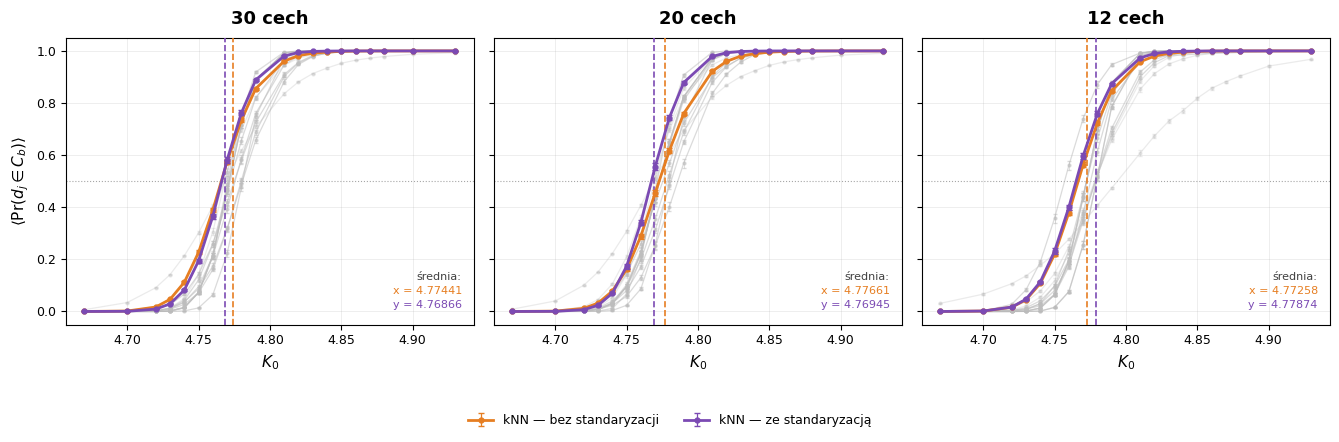


TRANSITION: AB
saved: /home/mariuszoslaw/uni/masters/Results/figures_feature_selection/AB_supervised_comparison.pdf
saved: /home/mariuszoslaw/uni/masters/Results/figures_feature_selection/AB_supervised_comparison.png


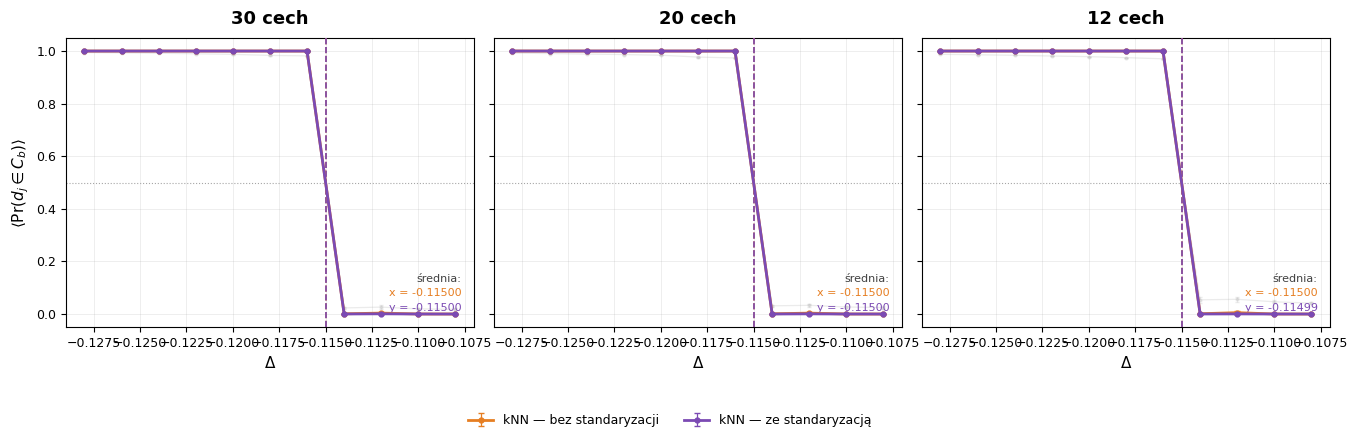


TRANSITION: BCb
saved: /home/mariuszoslaw/uni/masters/Results/figures_feature_selection/BCb_supervised_comparison.pdf
saved: /home/mariuszoslaw/uni/masters/Results/figures_feature_selection/BCb_supervised_comparison.png


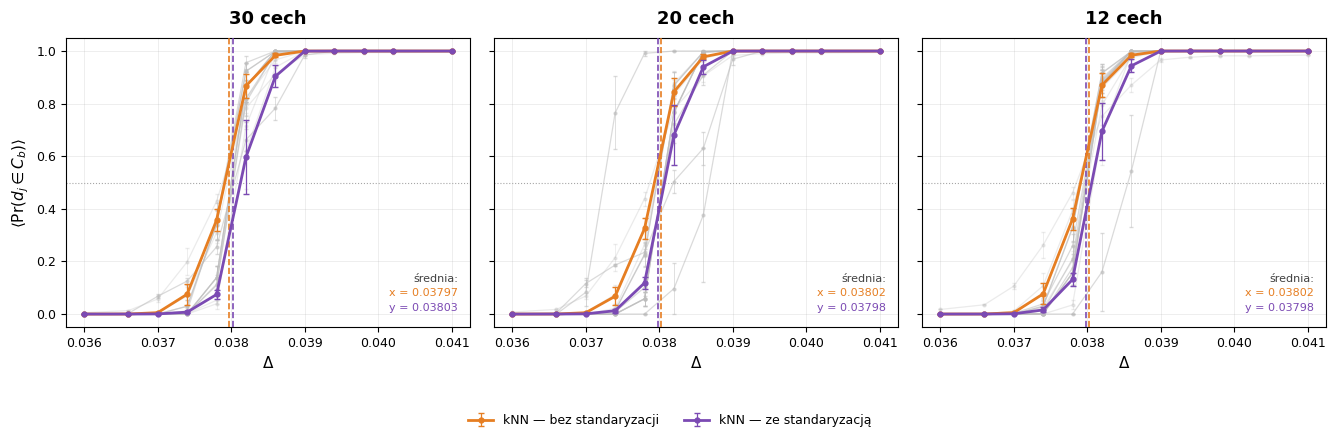

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

ROOT = Path(".").resolve()

OUTPUT_DIR = ROOT / "figures_feature_selection"

FEATURE_SETS = [30, 20, 12]

TARGET_MODEL = "SVM (RBF)"
CALIBRATION = "uncalibrated"

FORMATS = ["pdf", "png"]
DPI = 300

# All other supervised models shown in gray
BACKGROUND_COLOR = "#BDBDBD"

# Neural Network
RAW_COLOR = "#E67E22"
STD_COLOR = "#7B4AB3"

# Mean critical values
RAW_MEAN_COLOR = RAW_COLOR
STD_MEAN_COLOR = STD_COLOR


# ============================================================
# TRANSITION SETTINGS
# ============================================================

TRANSITIONS = {
    "AC": {
        "folder": "AC",
        "prefix": "AC",
        "x_column": "K0",
        "crit_column": "K0_crit",
        "x_label": r"$K_0$",
        "output_name": "AC_supervised_comparison",
    },

    "AB": {
        "folder": "AB",
        "prefix": "AB",
        "x_column": "Delta",
        "crit_column": "Delta_crit",
        "x_label": r"$\Delta$",
        "output_name": "AB_supervised_comparison",
    },

    "BCb": {
        "folder": "BCb",
        "prefix": "BCb",
        "x_column": "Delta",
        "crit_column": "Delta_crit",
        "x_label": r"$\Delta$",
        "output_name": "BCb_supervised_comparison",
    },
}


# ============================================================
# LOAD DATA
# ============================================================

def load_transition_data(root, transition, standardized=False):

    settings = TRANSITIONS[transition]

    folder = root / "SUPERVISED" / settings["folder"]

    suffix = "_STD" if standardized else ""

    mean_path = (
        folder
        / f"{settings['prefix']}{suffix}_curve_mean.csv"
    )

    summary_path = (
        folder
        / f"{settings['prefix']}{suffix}_summary.csv"
    )

    if not mean_path.exists():
        raise FileNotFoundError(mean_path)

    if not summary_path.exists():
        raise FileNotFoundError(summary_path)

    mean_df = pd.read_csv(mean_path)
    summary_df = pd.read_csv(summary_path)

    return mean_df, summary_df


# ============================================================
# FILTER CURVE
# ============================================================

def filter_curve(
    df,
    feature_set,
    model,
    x_column,
):

    result = df[
        (df["feature_set"] == feature_set)
        & (df["model"] == model)
    ].copy()

    if "calibration" in result.columns:
        result = result[
            result["calibration"] == CALIBRATION
        ].copy()

    return result.sort_values(x_column)


# ============================================================
# GET CRITICAL VALUE FOR ONE MODEL
# ============================================================

def get_model_crit(
    summary_df,
    feature_set,
    model,
    crit_column,
):

    result = summary_df[
        (summary_df["feature_set"] == feature_set)
        & (summary_df["model"] == model)
    ].copy()

    if "calibration" in result.columns:
        result = result[
            result["calibration"] == CALIBRATION
        ].copy()

    if result.empty:
        return np.nan

    values = pd.to_numeric(
        result[crit_column],
        errors="coerce"
    ).dropna()

    if values.empty:
        return np.nan

    return values.iloc[0]


# ============================================================
# GET MEAN CRITICAL VALUE
# FOR ALL SUPERVISED MODELS
# ============================================================

def get_mean_crit(
    summary_df,
    feature_set,
    crit_column,
):

    values = []

    models = summary_df["model"].dropna().unique()

    for model in models:

        crit = get_model_crit(
            summary_df,
            feature_set,
            model,
            crit_column,
        )

        if np.isfinite(crit):
            values.append(crit)

    if not values:
        return np.nan

    return np.mean(values)


# ============================================================
# PLOT ONE PANEL
# ============================================================

def plot_transition_panel(
    ax,
    raw_mean,
    raw_summary,
    std_mean,
    std_summary,
    feature_set,
    transition,
):

    settings = TRANSITIONS[transition]

    x_column = settings["x_column"]
    crit_column = settings["crit_column"]
    x_label = settings["x_label"]

    # ========================================================
    # ALL OTHER SUPERVISED MODELS — RAW
    # ========================================================

    models = raw_mean["model"].dropna().unique()

    for model in models:

        curve = filter_curve(
            raw_mean,
            feature_set,
            model,
            x_column,
        )

        if curve.empty:
            continue

        ax.errorbar(
            curve[x_column],
            curve["mean"],
            yerr=curve["mean_err"],
            fmt="o-",
            color=BACKGROUND_COLOR,
            ecolor=BACKGROUND_COLOR,
            markersize=2,
            linewidth=0.9,
            capsize=1.5,
            elinewidth=0.6,
            alpha=0.55,
            zorder=1,
        )

    # ========================================================
    # ALL OTHER SUPERVISED MODELS — STD
    # ========================================================

    models_std = std_mean["model"].dropna().unique()

    for model in models_std:

        curve = filter_curve(
            std_mean,
            feature_set,
            model,
            x_column,
        )

        if curve.empty:
            continue

        ax.errorbar(
            curve[x_column],
            curve["mean"],
            yerr=curve["mean_err"],
            fmt="o-",
            color=BACKGROUND_COLOR,
            ecolor=BACKGROUND_COLOR,
            markersize=2,
            linewidth=0.9,
            capsize=1.5,
            elinewidth=0.6,
            alpha=0.30,
            zorder=1,
        )

    # ========================================================
    # kNN — WITHOUT STANDARDIZATION
    # ========================================================

    raw_knn = filter_curve(
        raw_mean,
        feature_set,
        TARGET_MODEL,
        x_column,
    )

    if not raw_knn.empty:

        ax.errorbar(
            raw_knn[x_column],
            raw_knn["mean"],
            yerr=raw_knn["mean_err"],
            fmt="o-",
            color=RAW_COLOR,
            ecolor=RAW_COLOR,
            markersize=3.5,
            linewidth=2.0,
            capsize=2.5,
            elinewidth=0.9,
            label="kNN — bez standaryzacji",
            zorder=4,
        )

    # ========================================================
    # kNN — WITH STANDARDIZATION
    # ========================================================

    std_knn = filter_curve(
        std_mean,
        feature_set,
        TARGET_MODEL,
        x_column,
    )

    if not std_knn.empty:

        ax.errorbar(
            std_knn[x_column],
            std_knn["mean"],
            yerr=std_knn["mean_err"],
            fmt="o-",
            color=STD_COLOR,
            ecolor=STD_COLOR,
            markersize=3.5,
            linewidth=2.0,
            capsize=2.5,
            elinewidth=0.9,
            label="kNN — ze standaryzacją",
            zorder=5,
        )

    # ========================================================
    # MEAN CRITICAL VALUES
    # ========================================================

    raw_mean_crit = get_mean_crit(
        raw_summary,
        feature_set,
        crit_column,
    )

    std_mean_crit = get_mean_crit(
        std_summary,
        feature_set,
        crit_column,
    )

    # ========================================================
    # RAW MEAN
    # ========================================================

    if np.isfinite(raw_mean_crit):

        ax.axvline(
            raw_mean_crit,
            color=RAW_MEAN_COLOR,
            linestyle="--",
            linewidth=1.2,
            zorder=3,
        )

    # ========================================================
    # STD MEAN
    # ========================================================

    if np.isfinite(std_mean_crit):

        ax.axvline(
            std_mean_crit,
            color=STD_MEAN_COLOR,
            linestyle="--",
            linewidth=1.2,
            zorder=3,
        )

    # ========================================================
    # CRITICAL VALUE LABELS
    # ========================================================

    ax.text(
        0.97,
        0.15,
        "średnia:",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        color="0.25",
    )

    if np.isfinite(raw_mean_crit):

        ax.text(
            0.97,
            0.10,
            f"x = {raw_mean_crit:.5f}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8,
            color=RAW_MEAN_COLOR,
        )

    if np.isfinite(std_mean_crit):

        ax.text(
            0.97,
            0.05,
            f"y = {std_mean_crit:.5f}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8,
            color=STD_MEAN_COLOR,
        )

    # ========================================================
    # p = 0.5
    # ========================================================

    ax.axhline(
        0.5,
        color="0.65",
        linestyle=":",
        linewidth=0.8,
        zorder=0,
    )

    # ========================================================
    # PANEL TITLE
    # ========================================================

    ax.set_title(
        f"{feature_set} cech",
        fontsize=13,
        fontweight="bold",
        pad=10,
    )

    # ========================================================
    # AXES
    # ========================================================

    ax.set_xlabel(
        x_label,
        fontsize=11,
    )

    ax.set_ylim(
        -0.05,
        1.05,
    )

    ax.grid(
        alpha=0.25,
        linewidth=0.6,
    )

    ax.tick_params(
        axis="both",
        labelsize=9,
    )


# ============================================================
# CREATE ONE FIGURE FOR ONE TRANSITION
# ============================================================

def make_transition_figure(transition):

    settings = TRANSITIONS[transition]

    # --------------------------------------------------------
    # LOAD RAW
    # --------------------------------------------------------

    raw_mean, raw_summary = load_transition_data(
        ROOT,
        transition,
        standardized=False,
    )

    # --------------------------------------------------------
    # LOAD STANDARDIZED
    # --------------------------------------------------------

    std_mean, std_summary = load_transition_data(
        ROOT,
        transition,
        standardized=True,
    )

    # --------------------------------------------------------
    # FIGURE
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(13.5, 4.5),
        sharey=True,
    )

    # --------------------------------------------------------
    # PANELS
    # --------------------------------------------------------

    for ax, feature_set in zip(
        axes,
        FEATURE_SETS,
    ):

        plot_transition_panel(
            ax=ax,
            raw_mean=raw_mean,
            raw_summary=raw_summary,
            std_mean=std_mean,
            std_summary=std_summary,
            feature_set=feature_set,
            transition=transition,
        )

    # --------------------------------------------------------
    # Y LABEL
    # --------------------------------------------------------

    axes[0].set_ylabel(
        r"$\langle \Pr(d_j\in C_b)\rangle$",
        fontsize=11,
    )

    # --------------------------------------------------------
    # LEGEND
    # --------------------------------------------------------

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.025),
        ncol=2,
        frameon=False,
        fontsize=9,
    )

    # --------------------------------------------------------
    # LAYOUT
    # --------------------------------------------------------

    plt.tight_layout(
        rect=[
            0.0,
            0.09,
            1.0,
            0.96,
        ]
    )

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    for extension in FORMATS:

        output_path = (
            OUTPUT_DIR
            / f"{settings['output_name']}.{extension}"
        )

        fig.savefig(
            output_path,
            dpi=DPI,
            bbox_inches="tight",
        )

        print(
            f"saved: {output_path}"
        )

    plt.show()

    return fig, axes


# ============================================================
# RUN ALL THREE TRANSITIONS
# ============================================================

for transition in ["AC", "AB", "BCb"]:

    print()
    print("=" * 60)
    print(f"TRANSITION: {transition}")
    print("=" * 60)

    make_transition_figure(transition)